# PCA + SVM Baseline: Pushing the Limits
**Goal:** Classify next-day price direction (up/down) using PCA-compressed features + optimized SVM.

**Why this works as a strong baseline:**
- PCA handles multicollinearity in our ~90 features (many are z-scored versions of each other)
- SVM with RBF kernel can capture non-linear decision boundaries
- No sequential assumption — each row is treated independently (honest baseline)
- Fast to train → we can sweep a huge hyperparameter space

**Experiment plan:**
1. Load data, binarize target, define feature columns
2. Analyze PCA variance to pick component range
3. Coarse grid search (kernel × C × gamma × n_components)
4. Fine-grained search around best region
5. Final evaluation on held-out test set
6. Analysis: calibration, per-ticker breakdown, decision boundary intuition

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
from scipy.stats import loguniform, uniform

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

SEED = 42
np.random.seed(SEED)

## 1. Load Data & Prepare Binary Target

We use the existing temporal split (`_split` column). The target is binarized:
- `1` if next-day log return > 0 (price goes up)
- `0` if next-day log return ≤ 0 (price goes down)

Rows where target is exactly 0 are rare but we assign them to class 0 (no gain = no win).

In [3]:
# ── Adjust this path to where your CSVs live ──
DATA_DIR = Path("../data")

# Option A: separate files
if (DATA_DIR / "train_features.csv").exists():
    train_df = pd.read_csv(DATA_DIR / "train_features.csv", index_col="Date", parse_dates=True)
    val_df   = pd.read_csv(DATA_DIR / "val_features.csv",   index_col="Date", parse_dates=True)
    test_df  = pd.read_csv(DATA_DIR / "test_features.csv",  index_col="Date", parse_dates=True)
    full_df  = pd.concat([train_df, val_df, test_df])
    full_df["_split"] = "unknown"
    full_df.loc[train_df.index, "_split"] = "train"
    full_df.loc[val_df.index,   "_split"] = "val"
    full_df.loc[test_df.index,  "_split"] = "test"
# Option B: single file with _split column
elif (DATA_DIR / "features.csv").exists():
    full_df = pd.read_csv(DATA_DIR / "features.csv", index_col="Date", parse_dates=True)
else:
    raise FileNotFoundError(f"Put your data CSVs in {DATA_DIR.resolve()}")

print(f"Total rows: {len(full_df):,}")
print(f"Split distribution:\n{full_df['_split'].value_counts()}")
print(f"Tickers: {full_df['ticker'].nunique()} → {sorted(full_df['ticker'].unique())}")

Total rows: 13,475
Split distribution:
_split
train    10559
test      1464
val       1452
Name: count, dtype: int64
Tickers: 6 → ['AVAX-USD', 'BNB-USD', 'BTC-USD', 'ETH-USD', 'SOL-USD', 'XRP-USD']


In [4]:
# ── Define feature columns (exclude meta + target + raw OHLCV) ──
META_COLS = {'ticker', '_split', 'target', 'target_scale', 'target_mu',
             'Close', 'High', 'Low', 'Open', 'Volume'}

FEATURE_COLS = [c for c in full_df.columns if c not in META_COLS]
print(f"Feature columns ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

Feature columns (90):
['atr_norm', 'bb_pct_b', 'bull_regime', 'close_position', 'dow_sin', 'dow_cos', 'log_close_return_1', 'log_close_return_3', 'log_close_return_5', 'log_close_return_10', 'log_close_return_20', 'log_low_return_1', 'log_low_return_3', 'log_low_return_5', 'log_low_return_10', 'log_low_return_20', 'log_high_return_1', 'log_high_return_3', 'log_high_return_5', 'log_high_return_10', 'log_high_return_20', 'log_open_return_1', 'log_open_return_3', 'log_open_return_5', 'log_open_return_10', 'log_open_return_20', 'entropy', 'vol_5', 'vol_10', 'vol_20', 'vol_60', 'high_vol_regime', 'kurt', 'log_volume', 'macd_hist', 'range', 'ret_autocorr', 'roc_10', 'rsi_14', 'skew', 'dev_10', 'dev_20', 'dev_50', 'dev_100', 'volume_return', 'volume_z20', 'vol_ratio', 'z_log_close_return_1', 'z_log_close_return_3', 'z_log_close_return_5', 'z_log_close_return_10', 'z_log_close_return_20', 'z_log_low_return_1', 'z_log_low_return_3', 'z_log_low_return_5', 'z_log_low_return_10', 'z_log_low_return

In [5]:
# ── Binarize target ──
full_df['direction'] = (full_df['target'] > 0).astype(int)

# Split
train_mask = full_df['_split'] == 'train'
val_mask   = full_df['_split'] == 'val'
test_mask  = full_df['_split'] == 'test'

X_train = full_df.loc[train_mask, FEATURE_COLS].values
X_val   = full_df.loc[val_mask,   FEATURE_COLS].values
X_test  = full_df.loc[test_mask,  FEATURE_COLS].values

y_train = full_df.loc[train_mask, 'direction'].values
y_val   = full_df.loc[val_mask,   'direction'].values
y_test  = full_df.loc[test_mask,  'direction'].values

# Drop any rows with NaN in features
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    mask = ~np.isnan(X).any(axis=1)
    print(f"{name}: {mask.sum():,}/{len(mask):,} clean rows ({(~mask).sum()} dropped)")

clean_train = ~np.isnan(X_train).any(axis=1)
clean_val   = ~np.isnan(X_val).any(axis=1)
clean_test  = ~np.isnan(X_test).any(axis=1)

X_train, y_train = X_train[clean_train], y_train[clean_train]
X_val,   y_val   = X_val[clean_val],     y_val[clean_val]
X_test,  y_test  = X_test[clean_test],   y_test[clean_test]

print(f"\nClass balance (train): {y_train.mean():.3f} (fraction up)")
print(f"Class balance (val):   {y_val.mean():.3f}")
print(f"Class balance (test):  {y_test.mean():.3f}")

train: 10,559/10,559 clean rows (0 dropped)
val: 1,452/1,452 clean rows (0 dropped)
test: 1,464/1,464 clean rows (0 dropped)

Class balance (train): 0.502 (fraction up)
Class balance (val):   0.487
Class balance (test):  0.487


## 2. PCA Variance Analysis

Before optimizing, let's see how many components capture most of the variance.
This tells us the effective dimensionality of our feature space — many of our ~90 features
are highly correlated (raw + z-scored pairs), so PCA should compress aggressively.

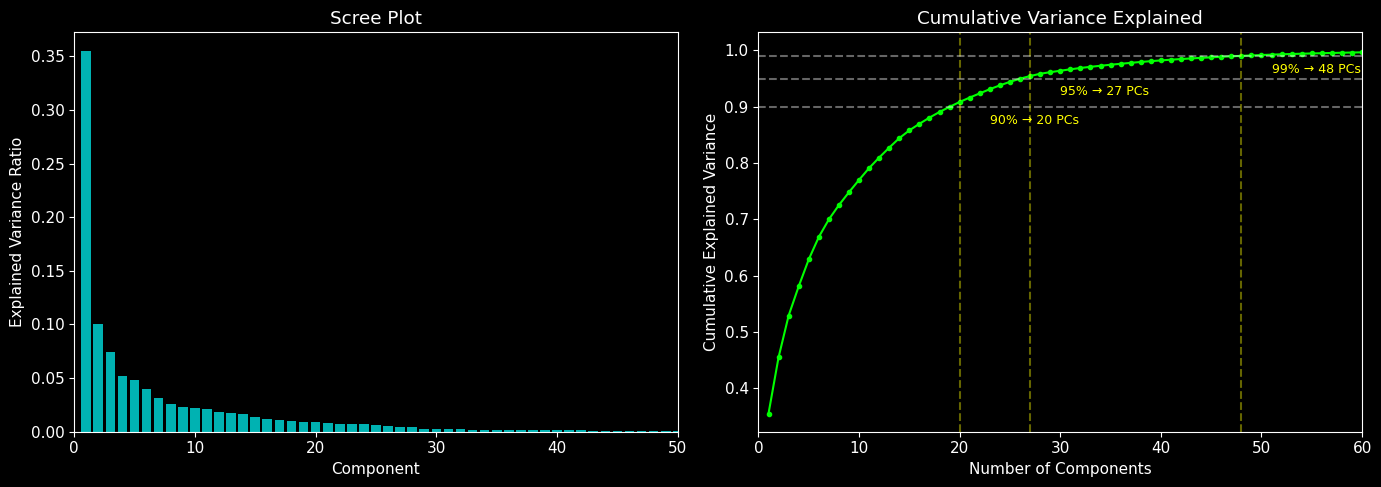

Components for 90% variance: 20
Components for 95% variance: 27
Components for 99% variance: 48


In [6]:
# Fit scaler + full PCA on training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, alpha=0.7, color='cyan')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')
axes[0].set_xlim(0, 50)

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='lime', markersize=3)
for thresh in [0.90, 0.95, 0.99]:
    n = np.searchsorted(cumvar, thresh) + 1
    axes[1].axhline(thresh, ls='--', alpha=0.4, color='white')
    axes[1].axvline(n, ls='--', alpha=0.4, color='yellow')
    axes[1].annotate(f'{thresh:.0%} → {n} PCs', xy=(n, thresh),
                     xytext=(n+3, thresh-0.03), fontsize=9, color='yellow')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xlim(0, min(60, len(cumvar)))

plt.tight_layout()
plt.show()

print(f"Components for 90% variance: {np.searchsorted(cumvar, 0.90)+1}")
print(f"Components for 95% variance: {np.searchsorted(cumvar, 0.95)+1}")
print(f"Components for 99% variance: {np.searchsorted(cumvar, 0.99)+1}")

## 3. Quick Sanity Baselines

Before going heavy on optimization, let's see where naive approaches land.
This gives us a floor to beat and catches data issues early.

In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

baselines = {}

# Always predict majority class
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
baselines['majority_class'] = accuracy_score(y_val, dummy.predict(X_val))

# Random weighted
dummy_r = DummyClassifier(strategy='stratified', random_state=SEED)
dummy_r.fit(X_train, y_train)
baselines['random_weighted'] = accuracy_score(y_val, dummy_r.predict(X_val))

# Logistic Regression (L2) on scaled features — no PCA
pipe_lr = Pipeline([('scaler', StandardScaler()), ('lr', LogisticRegression(max_iter=1000, random_state=SEED))])
pipe_lr.fit(X_train, y_train)
baselines['logistic_reg'] = accuracy_score(y_val, pipe_lr.predict(X_val))

# Logistic Regression + PCA(20)
pipe_lr_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20, random_state=SEED)),
    ('lr', LogisticRegression(max_iter=1000, random_state=SEED))
])
pipe_lr_pca.fit(X_train, y_train)
baselines['logistic_pca20'] = accuracy_score(y_val, pipe_lr_pca.predict(X_val))

# Default SVM + PCA(20)
pipe_svm_default = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20, random_state=SEED)),
    ('svm', SVC(random_state=SEED))
])
pipe_svm_default.fit(X_train, y_train)
baselines['svm_default_pca20'] = accuracy_score(y_val, pipe_svm_default.predict(X_val))

print("=" * 50)
print("  SANITY BASELINES (val accuracy)")
print("=" * 50)
for name, acc in sorted(baselines.items(), key=lambda x: x[1]):
    marker = " ◀ beat this" if name == 'majority_class' else ""
    print(f"  {name:25s}  {acc:.4f}{marker}")
print("=" * 50)

  SANITY BASELINES (val accuracy)
  majority_class             0.4869 ◀ beat this
  random_weighted            0.5048
  logistic_pca20             0.5331
  logistic_reg               0.5351
  svm_default_pca20          0.5406
